# Вариант 2

### 1. Математическая модель задачи

Пусть $x_1, x_2$ — объемы выпуска продукции первого и второго вида соответственно.
Целевая функция — суммарный доход $I$:
$$I(x_1, x_2) = x_1(A - a x_1) + x_2(B - b x_2) \to \max$$
При ограничении по объему производства:
$$x_1 + x_2 = C$$
И условиях неотрицательности:
$$x_1 \ge 0, x_2 \ge 0$$

Для варианта №2 параметры: $C = 175, A = 335, B = 135, a = 2.4, b = 1.2$.
Модель:
$$I = x_1(335 - 2.4 x_1) + x_2(135 - 1.2 x_2) \to \max$$
$$x_1 + x_2 = 175, \quad x_1, x_2 \ge 0$$


### 2-5. Решение в среде Python (ОПГ, Графический метод, Метод Лагранжа)

10
ОПГ: x1 = 86.1102, x2 = 88.8898
I=13569.444441457237
Лагранж: x1 = 86.1111, x2 = 88.8889
IL=13569.470253918


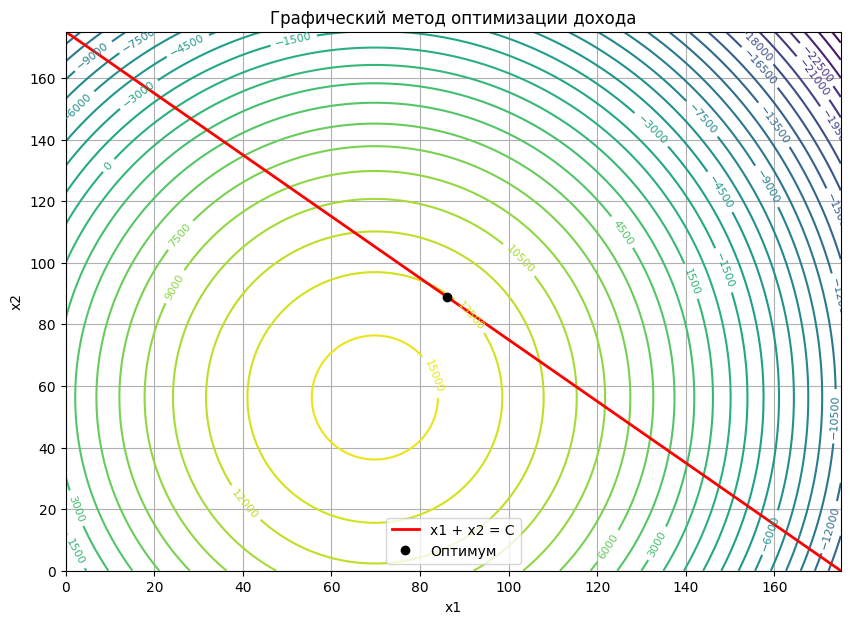

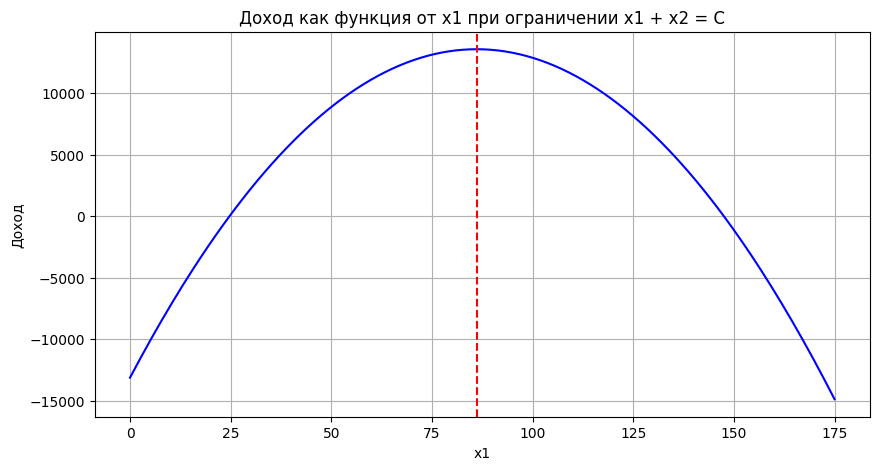

In [4]:
import numpy as np
import matplotlib.pyplot as plt

C, A, B, a, b = 175, 335, 135, 2.4, 1.2
x1, x2, t, e = 0.0, float(C), 0.1, 0.01

steps = 0
while True:
    g = (A - 2 * a * x1) - (B - 2 * b * x2)
    steps+=1
    if abs(g) < e:
        break
    x1 = x1 + t * g
    x2 = C - x1
I = x1*(A-a*x1)+x2*(B-b*x2)

L1 = (A - B + 2 * b * C) / (2 * (a + b))
L2 = C - L1
IL =  L1*(A-a*L1)+x2*(B-b*L2)

print(steps)
print(f"ОПГ: x1 = {x1:.4f}, x2 = {x2:.4f}")
print(f"{I=}")
print(f"Лагранж: x1 = {L1:.4f}, x2 = {L2:.4f}")
print(f"{IL=}")

m1 = np.linspace(0, C, 200)
m2 = np.linspace(0, C, 200)
X, Y = np.meshgrid(m1, m2)
Z = X * (A - a * X) + Y * (B - b * Y)

plt.figure(figsize=(10, 7))
cp = plt.contour(X, Y, Z, 30, cmap='viridis')
plt.clabel(cp, inline=True, fontsize=8)
plt.plot([0, C], [C, 0], 'r', linewidth=2, label='x1 + x2 = C')
plt.plot(x1, x2, 'ko', label='Оптимум')
plt.title('Графический метод оптимизации дохода')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True)
plt.show()

v = np.linspace(0, C, 200)
f = v * (A - a * v) + (C - v) * (B - b * (C - v))
plt.figure(figsize=(10, 5))
plt.plot(v, f, 'b')
plt.axvline(x1, color='r', linestyle='--')
plt.title('Доход как функция от x1 при ограничении x1 + x2 = C')
plt.xlabel('x1')
plt.ylabel('Доход')
plt.grid(True)
plt.show()